# Lab8 - Noisy annotators 2

Credits:

- the notebook is originally created by Daniel Kałuża
- modified and extended by Sebastian Stawicki and Piotr Biczyk

In real life annotation scenarios, we usually obtain annotations from multiple annotators. Moreover, we cannot assume that annotators are perfect, i.e. we know they certainly make mistakes. Moreover, their performance may vary, due to different levels of expertise, fatigue, or other factors. There can be even cases when the same expert annotates similar data differently, e.g., when the data is ambiguous or when the annotator is tired.

This time, we are going to continue exploring the stated problem. We will use the same setup (dataset and model) as in the previous lab. However, we will now employ more sophisticated methods to model the annotators' consensus on the labels.

### Why this matters in practice

Most "supervised learning" tutorials assume you have clean ground-truth labels and the only question is which model to train. In real annotation projects this assumption almost never holds:

- **Medical imaging.** A radiologist labels a tumor as malignant or benign, but the only true ground truth is a biopsy - which is invasive and not always done. CAD systems are trained on labels from multiple radiologists who disagree on perhaps 20-30% of cases.
- **Crowdsourcing platforms** (Amazon Mechanical Turk, Prolific). You get cheap labels at scale, but worker quality varies wildly: experts, novices, bots, and occasional adversaries all in the same pool.
- **Subjective tasks.** Sentiment analysis, content moderation, image aesthetics - there is no "correct" answer, only consensus among human raters.
- **Specialist domains.** Legal document review, scientific paper classification, rare disease diagnosis - even domain experts disagree, sometimes substantially.

In all of these cases, the question shifts from "how do I train a good model on clean data?" to "given that my labels are noisy and my annotators are unequal, how do I extract a reliable signal?" That is exactly what this lab is about.

### The chicken-and-egg problem

The core difficulty in this lab can be stated in one sentence: *we want to know how good each annotator is, but we can't measure that without ground truth - and we want to estimate ground truth, but we can't do that well without knowing how much to trust each annotator.*

Three approaches to break this circularity, in increasing sophistication:

1. **Majority voting.** Treat all annotators as equally trustworthy, take the most common label per sample. Simple and surprisingly hard to beat - but it fails when novices outnumber experts (the wrong majority drowns out the right minority).

2. **Weighted voting.** Give each annotator a weight reflecting their reliability. But where do the weights come from?

3. **Joint estimation (this lab).** Estimate annotator reliability and ground truth *simultaneously* using the EM algorithm. Start with a guess (e.g. majority voting), use it to score annotators, use those scores to refine the guess, repeat until stable.

The third approach is what makes this lab non-trivial - it's also why we spend section 3 on EM before getting to the consensus algorithm in section 4.

## 0. Import libraries

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## 1. Data preparation (reuse your implementation from the previous lab session)

We will use MNIST dataset - the same as in one of the previous labs.

In [58]:
from sklearn.datasets import fetch_openml

bunch = fetch_openml('mnist_784', return_X_y=False)
X = bunch.data.to_numpy()
y = bunch.target.to_numpy()
y.shape
print(X.shape)


(70000, 784)


### One hot encoding of labels

We will assume that the annotators can label the samples with more than one class. This might reflect the annotators' uncertainty but still conveys valuable information, e.g., "It looks like the sample could be A, C, or D, but certainly not B or E".

Therefore, we will also transform our ground truth into an appropriate representation. Apply one-hot encoding to `y` so that the `i`-th element corresponding to a given sample is `1` if the sample belongs to class `i`, and `0` otherwise.

In [59]:
# write your code here
from sklearn.preprocessing import OneHotEncoder

y = y.astype(int).reshape(-1, 1)    #Zamieniam y na typ int i zamieniam 1 wektor wielowymiarowy na wiele wektorów jednowymiarowych (dla OneHotEncoder)
enc = OneHotEncoder(sparse_output=False)
Y = enc.fit_transform(y).astype(int)    #One-Hot encoding

print(Y[:5])

[[0 0 0 0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]]


### Load the annotations

This time, instead of simulating the entire active learning annotation process, we will look at a particular state of our system. Specifically, we have a record of annotations up to a certain point in time.

There are `N = 70000` samples (MNIST images) in the dataset and there are `K` possible decision classes (`'0', '1', ..., '9'`). In our case, `L = 15` experts are involved in the annotation process. Each annotator can assign more than one class to a given sample, thereby expressing uncertainty in the assigned decision. Additionally, each sample may be labeled by one or more annotators, or not labeled at all.

We are going to use the annotations stored in the `Lab-07-noisy-annotators.npz` file. The `tags` array is of the shape `(N, K, L)` and it contains:

- `nan` if an annotator hasn't labelled this sample at all
- `0` if an annotator has labelled the sample and didn't indicate considered class
- `1` if an annotator has labelled the sample and indicated that it belongs to considered class

\* There is also a more challenging version stored under `tags_hard` variable, where there are `L = 30` experts involved in the labeling process.


In [60]:
noisy_annotators = np.load('Lab-07-noisy-annotators.npz')
tags = noisy_annotators['tags']
tags_hard = noisy_annotators['tags_hard']

print(f"Annotations (15 experts) shape: {tags.shape}")
print(tags[5:7, :, :])

Annotations (15 experts) shape: (70000, 10, 15)
[[[nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  1. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  1. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]]

 [[nan nan nan  0. nan nan  0. nan nan nan nan nan nan nan nan]
  [nan nan nan  1. nan nan  1. nan nan nan nan nan nan nan nan]
  [nan nan nan  0. nan nan  0. nan nan nan nan nan nan nan nan]
  [nan nan nan  1. nan nan  0. nan nan nan nan nan nan nan nan]
  [nan nan nan  1. nan nan  0. nan nan nan nan nan nan

## 2. Evaluate the experts' performance (reuse your implementation from the previous lab session)

Create a function that evaluates the experts' performance. It should be possible to present the result in the graphical form.

The function should take the ground truth `y` labels (one-hot encoded), the `tags` array, and an additional `performance_fun` parameter. 

The performance function can be one of the following:

- `recall` - in multilabel version, we can count it as correct if the annotator assigns the right class (the same as the ground truth class) to the sample, even if multiple classes are assigned. We do not penalize the annotator if multiple wrong classes are also assigned,
- `precision`
- `hamming loss`

Implement all of them and, optionally, propose your own performance functions.

In [61]:
def per_class_recall(true_labels, expert_tags):
    hit = (true_labels * expert_tags) > 0   # shape (n_samples, K)
    class_counts = true_labels.sum(axis=0)  # shape (K)
    # liczba trafień każdej klasy
    hits_per_class = hit.sum(axis=0)        # shape (K)
    # recall per class
    recall_per_class = np.divide(hits_per_class, class_counts, out=np.zeros_like(hits_per_class, dtype=float), where=class_counts != 0)
    return recall_per_class

def recall_fun(true_labels, expert_tags, average=True, per_class=False):
    if per_class:
        return per_class_recall(true_labels, expert_tags)
    else:
        hit = (true_labels * expert_tags).sum(axis=1) > 0
        return hit.mean() if average else hit


def precision_fun(true_labels, expert_tags, average=True):
    intersection = (true_labels * expert_tags).sum(axis=1)
    predicted = expert_tags.sum(axis=1)

    precision_sample = np.zeros_like(intersection, dtype=float)

    np.divide(intersection, predicted, out=precision_sample, where=predicted != 0)

    return precision_sample.mean() if average else precision_sample



def hamming_fun(true_labels, expert_tags, average=True):
    diff = (expert_tags != true_labels).mean(axis=1)
    return diff.mean() if average else diff

def expert_performance(ground_y, tags, perf_fun, per_class=False):
    
    if per_class and perf_fun==recall_fun:
        expert_perf = np.zeros((tags.shape[2], ground_y.shape[1]))
    else:
        expert_perf = np.zeros(tags.shape[2])

    for expert in range(tags.shape[2]):
        annotated = ~np.isnan(tags[:, 0, expert])
        expert_tags = tags[annotated, :, expert]
        true_labels = ground_y[annotated]

        if per_class and perf_fun==recall_fun:
            expert_perf[expert] = perf_fun(true_labels, expert_tags, per_class=per_class)
        else:
            expert_perf[expert] = perf_fun(true_labels, expert_tags)

    return expert_perf

def plot_expert_metrics(ground_y, tags):
    L = tags.shape[2]
    recall_scores = expert_performance(ground_y, tags, recall_fun)
    precision_scores = expert_performance(ground_y, tags, precision_fun)
    hamming_scores = expert_performance(ground_y, tags, hamming_fun)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # RECALL
    axes[0].bar(np.arange(L), recall_scores, color="steelblue")
    axes[0].set_title("Recall per expert")
    axes[0].set_xlabel("Expert ID")
    axes[0].set_ylabel("Recall")
    axes[0].set_xticks(np.arange(L))

    # PRECISION
    axes[1].bar(np.arange(L), precision_scores, color="seagreen")
    axes[1].set_title("Precision per expert")
    axes[1].set_xlabel("Expert ID")
    axes[1].set_ylabel("Precision")
    axes[1].set_xticks(np.arange(L))

    #HAMMING LOSS
    axes[2].bar(np.arange(L), hamming_scores, color="indianred")
    axes[2].set_title("Hamming loss per expert")
    axes[2].set_xlabel("Expert ID")
    axes[2].set_ylabel("Hamming loss")
    axes[2].set_xticks(np.arange(L))

    plt.tight_layout()
    plt.show()

#testowanie funkcji
a = np.array([[0, 0, 1, 0],
              [0, 1, 0, 0]])

b = np.array([[1, 0, 1, 0],
              [0, 1, 0, 0]])

#print(hamming_fun(a, b, average=False))

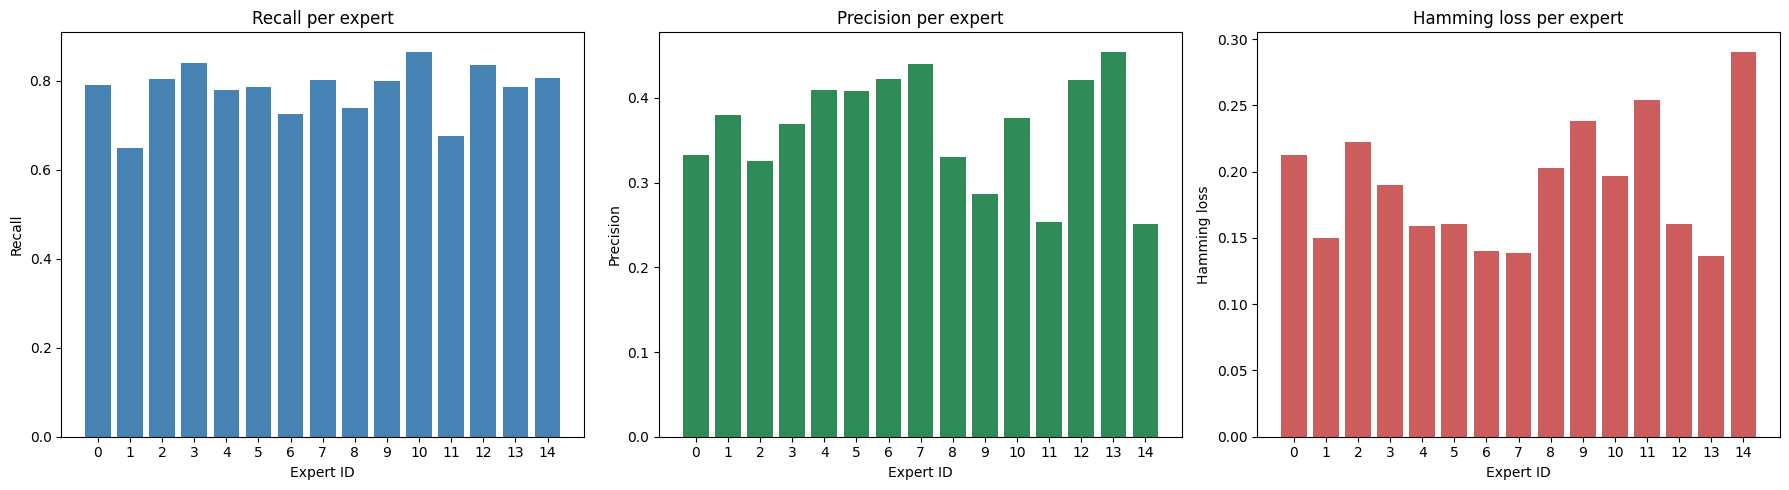

In [62]:
# write your code here
plot_expert_metrics(Y, tags)

## 3A*. Expectation Maximization Algorithm (you can skip this part if you are familiar with EM algorithm)

The Expectation Maximization (EM) algorithm is a technique for estimating the parameters of a statistical model when the data is incomplete or has missing values. Before applying the EM algorithm to the noisy annotators problem we will practice it on a simpler, more intuitive example.

---

### Maximum Likelihood Estimation (MLE)

Let us start however with Maximum Likelihood Estimation (MLE). MLE is a method of estimating the parameters of a statistical model by maximizing the likelihood function - the probability of observing the given data under the model. In other words, MLE finds the parameter values that make the observed data most probable.

Example: Suppose we toss a coin 10 times and observe 6 heads and 4 tails. We want to estimate the probability of getting heads - let's refer to it as $\theta$. We assume that the tosses are independent.

$$
L(\theta) = P(data|\theta) = \theta^6 (1 - \theta)^4
$$

$$
\hat{\theta} = \argmax_\theta L(\theta)
$$


Log-likelihood function:

$$
\log L(\theta) = 6 \log(\theta) + 4 \log(1 - \theta)
$$

To find the maximum likelihood estimate of $\theta$, we take the derivative of the log-likelihood function with respect to $\theta$ and set it to zero:

$$
\frac{d}{d\theta} \log L(\theta) = \frac{6}{\theta} - \frac{4}{1 - \theta} = 0
\ \\
\ \\
\frac{6}{\theta} = \frac{4}{1 - \theta}
\ \\
\ \\
6 \cdot (1 - \theta) = 4 \cdot \theta
\ \\
\ \\
\theta \cdot (6 + 4) = 6
\ \\
\ \\
\theta = \frac{6}{6+4} = 0.6
$$

---

### Expectation Maximization (EM)

Let's now consider a more complex situation. Suppose we have two coins, with probabilities $\theta_1$ and $\theta_2$ of getting heads. We refer to 10 tosses of one of the coins as a sample. However, we do not know which coin was used for each sample. We have a record of 6 such samples. What is hidden here is that we do not know which coin was used for each sample -- we only know the number of heads and tails in each sample. We can use the EM algorithm to estimate the parameters of the two coins.

- `HHTHTHHHTH` = 7xH + 3xT
- `TTTHTTHHTT` = 3xH + 7xT
- `HHHHHTTHTT` = 6xH + 4xT
- `HHTTTTTTTT` = 2xH + 8xT
- `HTHHHHTHHH` = 8xH + 2xT
- `TTTTTTTHTT` = 1xH + 9xT

1. Initial random guess of $\theta_1$ and $\theta_2$ (e.g. $\theta_1 = 0.45$, $\theta_2 = 0.55$)
1. E-step: calculate the expected number of heads and tails for each sample using the current estimates of $\theta_1$ and $\theta_2$.
   - compute the likelihood of each sample given the current estimates of $\theta_1$ and $\theta_2$
   - compute the probability of each sample being generated by each coin (use Bayes' theorem $P(A|B) = \frac{P(B|A) P(A)}{P(B)}$)
     $$ 
        P(coin_A | sample_i, \theta_1, \theta_2) = \frac{P(sample_i | coin_A, \theta_1) P(coin_A)}{P(sample_i| \theta_1) P(coin_A) + P(sample_i| \theta_2) P(coin_B)}
     $$
2. M-step: update the estimates of $\theta_1$ and $\theta_2$ based on the expected counts from the E-step - apply MLE.
3. Repeat steps 2 and 3 until convergence (i.e., the estimates do not change significantly).
4. Return the final estimates of $\theta_1$ and $\theta_2$.





## 3B*. Try it on your own (you can skip this part if you are familiar with EM algorithm)

Let's try it for a Gaussian Mixture Model.

Note the structural parallel to the coin example: the latent variable is "which component generated this point" (analogous to "which coin"), and the parameters are the per-component (μ, σ) (analogous to the per-coin θ). The E-step computes a soft assignment over latents; the M-step is MLE under those soft assignments. The only thing that changes between the two problems is the form of the per-component likelihood — Bernoulli for coins, Gaussian for the GMM.

**Setup.** Pick weights `w₁, w₂, w₃` (summing to 1), means `μ₁, μ₂, μ₃`, and standard deviations `σ₁, σ₂, σ₃` for a three-component 1D Gaussian mixture. Pick a sample size `N`.

**Generate data.** Draw `⌊w_k · N⌋` samples from `N(μ_k, σ_k)` for each component, then concatenate. This gives you a 1D array of `N` points whose true component assignments are known to you (but should be hidden from your EM).

**Implement EM.** Treat the component assignment of each point as the latent variable (analogous to "which coin?" in the previous section). Derive and implement:
- *E-step:* compute the `r_{i,k} = P(z_i = k | x_i, θ)` for each point and component, given the current parameter estimates.
- *M-step:* given the above, update `w_k`, `μ_k`, `σ_k` in closed form (the GMM updates are weighted analogues of the standard mean/variance formulas - derive them yourself or look them up; both are valid).
- Iterate until the log-likelihood change per iteration drops below e.g. `1e-4`, with a hard cap of 100 iterations.

**Evaluate.** Compare the estimated `(w, μ, σ)` triples to the true ones. Plot the data histogram, the true mixture density, and your estimated mixture density on a single figure.

--- 

E.g.,

```python
N = 10000

w1, mu1, sigma1 = 0.4, 20, 2
w2, mu2, sigma2 = 0.3, 10, 10
w3, mu3, sigma3 = 0.3, -20, 5

def gaussian(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

data1 = np.random.normal(loc=mu1, scale=sigma1, size=int(N * w1))
data2 = np.random.normal(loc=mu2, scale=sigma2, size=int(N * w2))
data3 = np.random.normal(loc=mu3, scale=sigma3, size=int(N * w3))
data = np.concatenate([data1, data2, data3])

x = np.linspace(min(data), max(data), 1000)    
gauss1 = w1 * gaussian(x, mu1, sigma1)
gauss2 = w2 * gaussian(x, mu2, sigma2)
gauss3 = w3 * gaussian(x, mu3, sigma3)

plt.hist(data, bins=100, density=True, alpha=0.5)
plt.plot(x, gauss1, label='True Gaussian 1')
plt.plot(x, gauss2, label='True Gaussian 2')
plt.plot(x, gauss3, label='True Gaussian 3')
plt.legend()
plt.show()
```

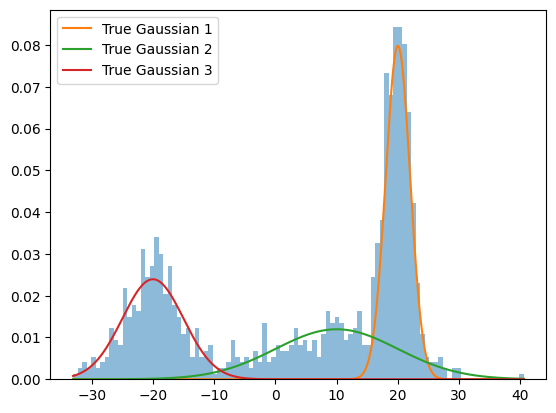

In [63]:
N = 1000

w1, mu1, sigma1 = 0.4, 20, 2
w2, mu2, sigma2 = 0.3, 10, 10
w3, mu3, sigma3 = 0.3, -20, 5

def gaussian(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

data1 = np.random.normal(loc=mu1, scale=sigma1, size=int(N * w1))
data2 = np.random.normal(loc=mu2, scale=sigma2, size=int(N * w2))
data3 = np.random.normal(loc=mu3, scale=sigma3, size=int(N * w3))
data = np.concatenate([data1, data2, data3])

x = np.linspace(min(data), max(data), 1000)    
gauss1 = w1 * gaussian(x, mu1, sigma1)
gauss2 = w2 * gaussian(x, mu2, sigma2)
gauss3 = w3 * gaussian(x, mu3, sigma3)

plt.hist(data, bins=100, density=True, alpha=0.5)
plt.plot(x, gauss1, label='True Gaussian 1')
plt.plot(x, gauss2, label='True Gaussian 2')
plt.plot(x, gauss3, label='True Gaussian 3')
plt.legend()
plt.show()


Iter   0: log-likelihood = -40332.679
  weights: [0.19755282 0.56326233 0.23918485]
  mus    : [-18.71234822   7.1655378   19.42915894]
  sigmas : [ 9.03720516 15.62015324  5.61326168]


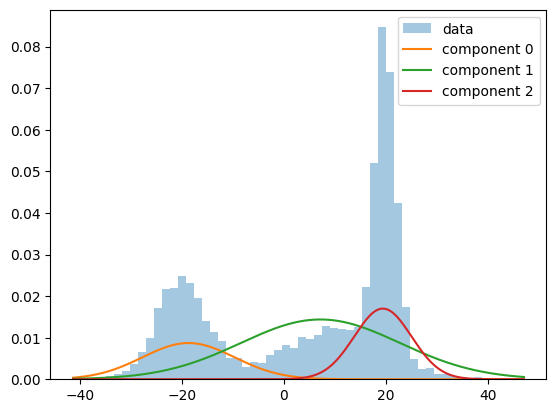

Iter   1: log-likelihood = -38447.147
  weights: [0.22481061 0.45309828 0.32209111]
  mus    : [-19.81316278   7.0340064   19.4158533 ]
  sigmas : [ 5.95180449 15.25230402  3.53531247]


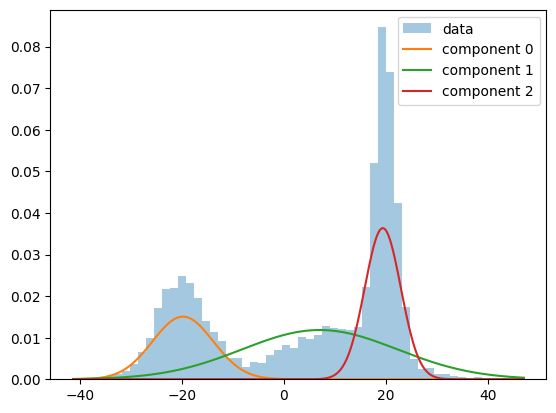

Iter  10: log-likelihood = -37278.320
  weights: [0.29266067 0.29789118 0.40944815]
  mus    : [-20.16682116   9.05520713  20.00529211]
  sigmas : [ 4.82544809 10.62818876  2.04003514]


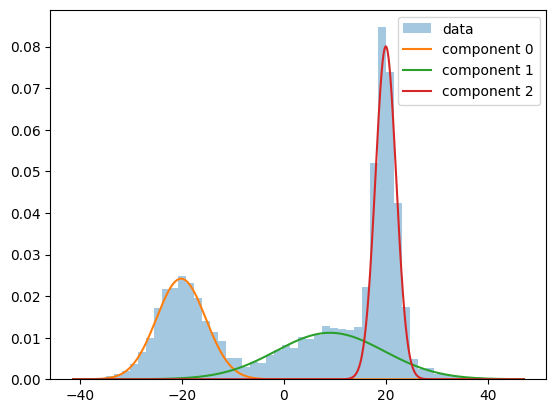

Iter  20: log-likelihood = -37270.905
  weights: [0.30051151 0.29955766 0.39993083]
  mus    : [-19.97634572   9.94776855  20.02784425]
  sigmas : [ 4.96647912 10.09064767  1.99353696]


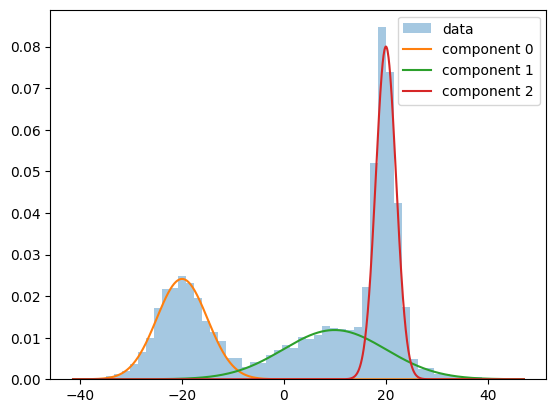

Iter  30: log-likelihood = -37270.861
  weights: [0.30100452 0.30001832 0.39897716]
  mus    : [-19.96296181  10.01318363  20.02962746]
  sigmas : [ 4.97701517 10.05782672  1.98878531]


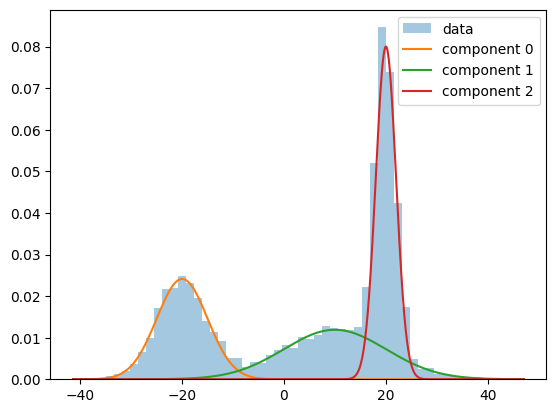

Iter  40: log-likelihood = -37270.861
  weights: [0.30103806 0.30005719 0.39890475]
  mus    : [-19.96204656  10.01786282  20.02975598]
  sigmas : [ 4.97773773 10.05559775  1.9884194 ]


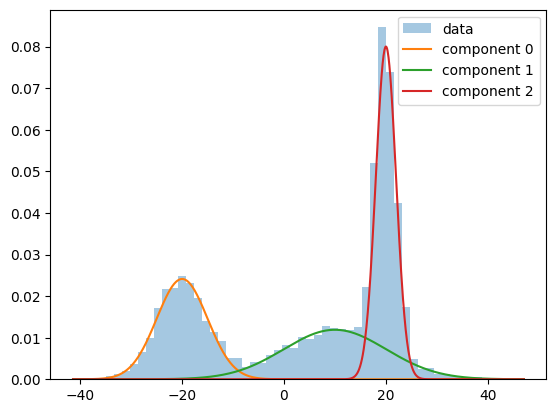

Converged at iteration 40


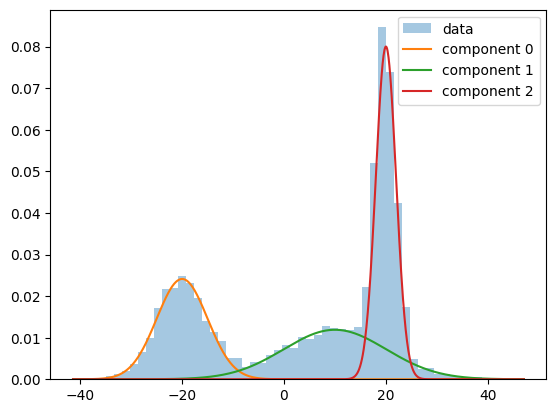


Final parameters:
weights: [0.30103806 0.30005719 0.39890475]
mus    : [-19.96204656  10.01786282  20.02975598]
sigmas : [ 4.97773773 10.05559775  1.9884194 ]


In [64]:
N = 10000

w1, mu1, sigma1 = 0.4, 20, 2
w2, mu2, sigma2 = 0.3, 10, 10
w3, mu3, sigma3 = 0.3, -20, 5

def gaussian(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

data1 = np.random.normal(loc=mu1, scale=sigma1, size=int(N * w1))
data2 = np.random.normal(loc=mu2, scale=sigma2, size=int(N * w2))
data3 = np.random.normal(loc=mu3, scale=sigma3, size=int(N * w3))
data = np.concatenate([data1, data2, data3])
data = data.reshape(-1, 1)   # (N, 1)


def E_step(x, weights, mus, sigmas):
    """
    x: (N, 1)
    weights: (K,)
    mus: (K,)
    sigmas: (K,)
    """
    N = x.shape[0]
    K = weights.shape[0]

    # g[n,k] = w_k * N(x_n | mu_k, sigma_k)
    # wektorowo: dla każdego k liczymy pdf po wszystkich n
    gauss_vals = np.zeros((N, K))
    for k in range(K):
        gauss_vals[:, k] = weights[k] * norm.pdf(x[:, 0], loc=mus[k], scale=sigmas[k])

    # normalizacja po klastrach
    denom = gauss_vals.sum(axis=1, keepdims=True)
    # zabezpieczenie przed dzieleniem przez 0
    denom[denom == 0] = 1e-12

    responsibilities = gauss_vals / denom
    return responsibilities   # (N, K)


def M_step(x, responsibilities):
    """
    x: (N, 1)
    responsibilities: (N, K)
    """
    N, K = responsibilities.shape
    Nk = responsibilities.sum(axis=0)  # (K,)

    # nowe wagi
    weights = Nk / N

    # nowe średnie
    mus = np.zeros(K)
    for k in range(K):
        mus[k] = np.sum(responsibilities[:, k] * x[:, 0]) / Nk[k]

    # nowe sigmy
    sigmas = np.zeros(K)
    for k in range(K):
        diff = x[:, 0] - mus[k]
        sigmas[k] = np.sqrt(np.sum(responsibilities[:, k] * diff**2) / Nk[k])

    # zabezpieczenie przed zbyt małą sigma
    sigmas = np.maximum(sigmas, 1e-6)

    return weights, mus, sigmas


def log_likelihood(x, weights, mus, sigmas):
    N = x.shape[0]
    K = weights.shape[0]
    vals = np.zeros((N, K))
    for k in range(K):
        vals[:, k] = weights[k] * norm.pdf(x[:, 0], loc=mus[k], scale=sigmas[k])
    s = vals.sum(axis=1)
    s[s == 0] = 1e-12
    return np.sum(np.log(s))


# EM loop

K = 3
np.random.seed(0)

# inicjalizacja
weights = np.ones(K) / K
mus = np.linspace(data.min(), data.max(), K)
sigmas = np.full(K, data.std())

max_iter = 100
tol = 1e-6
prev_ll = None
x_plot = np.linspace(data.min() - 5, data.max() + 5, 1000)

for it in range(0, max_iter + 1):
    # E-step
    resp = E_step(data, weights, mus, sigmas)

    # M-step
    weights, mus, sigmas = M_step(data, resp)

    # log-likelihood
    ll = log_likelihood(data, weights, mus, sigmas)

    if it % 10 == 0 or it == 1:
        print(f"Iter {it:3d}: log-likelihood = {ll:.3f}")
        print("  weights:", weights)
        print("  mus    :", mus)
        print("  sigmas :", sigmas)

        plt.hist(data[:, 0], bins=50, density=True, alpha=0.4, label="data")

        for k in range(K):
            plt.plot(
                x_plot,
                weights[k] * norm.pdf(x_plot, loc=mus[k], scale=sigmas[k]),
                label=f"component {k}"
            )

        plt.legend()
        plt.show()

    if prev_ll is not None and abs(ll - prev_ll) < tol:
        print(f"Converged at iteration {it}")
        break
    prev_ll = ll

# wizualizacja

x_plot = np.linspace(data.min() - 5, data.max() + 5, 1000)

plt.hist(data[:, 0], bins=50, density=True, alpha=0.4, label="data")

for k in range(K):
    plt.plot(
        x_plot,
        weights[k] * norm.pdf(x_plot, loc=mus[k], scale=sigmas[k]),
        label=f"component {k}"
    )

plt.legend()
plt.show()

print("\nFinal parameters:")
print("weights:", weights)
print("mus    :", mus)
print("sigmas :", sigmas)


[0.51403591 0.31283283 0.17313126]
[ 19.92597012 -19.62183384   5.09584716]
[3.30911976 5.24321766 5.99370576]


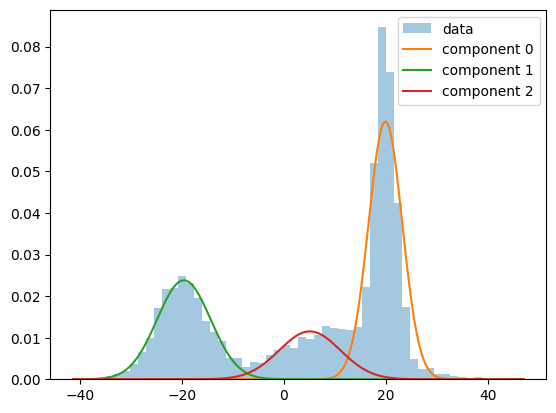

In [65]:
from sklearn.mixture import GaussianMixture

model = GaussianMixture(n_components=3).fit(data)

print(model.weights_)
print(model.means_[:, 0])
print(np.sqrt(model.covariances_[:, 0, 0]))

plt.hist(data[:, 0], bins=50, density=True, alpha=0.4, label="data")

for k in range(K):
    plt.plot(
        x_plot,
        model.weights_[k] * norm.pdf(x_plot, loc=model.means_[k, 0], scale=np.sqrt(model.covariances_)[k, 0, 0]),
        label=f"component {k}"
    )

plt.legend()
plt.show()

Once your implementation runs, compare your estimated (w, μ, σ) to sklearn.mixture.GaussianMixture(n_components=3).fit(data.reshape(-1, 1)). The numbers should match closely (up to label permutation - sklearn's component 0 is not necessarily your component 0).

Note: with the example parameters suggested above, EM will often converge to a wrong local optimum depending on initialization. Run it with several random seeds and observe the variance - this is a real and important property of EM, not a bug in your code. To verify your implementation works at all, try first on an easier setup with well-separated, similar-variance components (e.g. μ = [-5, 0, 5], σ = [1, 1, 1]).

## 4. Consensus voting algorithm

(Based on: http://www.umiacs.umd.edu/labs/cvl/pirl/vikas/publications/raykar_JMLR_2010_crowds.pdf)

In consensus voting, we estimate the performance of each expert utilizing their true positive rate (TPR) and true negative rate (TNR) for each class.

The proposed algorithm utilizes the Expectation-Maximization (EM) framework and follows the steps below:

1. Use the majority voting aproach to estimate initial ground truths.
2. Maximization step - estimate the performance of the experts based on the following equations:
     
$$
{TPR}_a = \frac{\sum_{x \in X} \hat{p}(y = 1 | x) \cdot p_a( y = 1 | x)}{\sum_{x \in X} \hat{p}(y = 1 | x) }
$$

$$
{TNR}_a = \frac{\sum_{x \in X} \hat{p}(y = 0 | x) \cdot p_a( y = 0 | x)}{\sum_{x \in X} \hat{p}(y = 0 | x) }
$$

3. Expectation step - estimate the probability distribution of classes for each sample based on the current estimation of experts' performance:
$$
p_{score}(y=1 | x) = p(y = 1) \cdot \prod_{a \in A } [{TPR}_a]^{p_a(y = 1 | x)} [1 - {TPR}_a]^{1 - p_a(y = 1 | x)}
$$

$$
p_{score}(y=0 | x) = p(y = 0) \cdot \prod_{a \in A } [{TNR}_a]^{p_a(y = 0 | x)} [1 - {TNR}_a]^{1 - p_a(y = 0 | x)}
$$

$$
\hat{p}(y = 1 | x) = \frac{p_{score}(y=1 | x)}{p_{score}(y=1 | x) + p_{score}(y=0 | x)}
$$

4. Repeat steps `2` and `3` until the probability distributions converge. 

Implement the consensus voting algorithm and estimate ground truth labels.The result should be a 2D array of shape `(N, K)`.


### Hints

**Multi-class via K independent binary problems.** The formulas above are written for binary `y ∈ {0, 1}`, but our problem has `K = 10` classes. The simplest way to reconcile this is to treat each of the 10 classes as a separate binary problem (one-vs-rest). You will end up with one `TPR_a` and one `TNR_a` per `(annotator, class)` pair, i.e. arrays of shape `(L, K)`, and you compute `p̂(y=1 | x)` independently for each class. The final `(N, K)` matrix is the stack of these per-class posteriors. Note - this is a simplification of the Raykar.

**Handling missing annotations (`NaN`).** The formulas implicitly assume every annotator labeled every sample. They didn't. When annotator `a` did not label sample `x`, the factor that annotator contributes to the product in the E-step should be `1` (no information, no influence). Equivalently, in the sums of the M-step, just skip those entries. **Do not** replace `NaN` with `0` in the data - that would tell the model the annotator confidently said "not this class," which is a different statement.

**Clip TPR/TNR away from 0 and 1.** If an annotator happens to be perfectly right (or wrong) on every sample, `TPR_a` or `1 - TPR_a` becomes exactly `0`, which produces `log(0) = -inf` and breaks the next E-step. Clip to e.g. `[1e-6, 1 - 1e-6]` after the M-step.

**Class prior `p(y=1)`.** The formula uses a class prior but doesn't say where it comes from. The Raykar paper re-estimates it each iteration as `p(y=1) = (1/N) Σᵢ p̂(yᵢ=1|xᵢ)`, treating it as another parameter learned by EM - this is the "correct" choice if you want to follow the paper. A simpler alternative is to fix it at `1/K = 0.1` (uniform) and ignore the issue. Both work. 

**Convergence.** A practical stopping criterion: stop when `max(|p̂_new - p̂_old|) < 1e-4`, with a hard cap of e.g. 50 iterations as a safety net. Print the iteration number and the max change per step so you can see EM working.

**Order of operations.** Note that the algorithm starts with the M-step rather than the textbook E-then-M order. This is because we initialize the *latent variable estimates* (the labels, via majority voting), not the *parameters* (TPR/TNR). Both formulations are valid EM; this one happens to be more convenient because majority voting gives a sensible label initialization for free.

**Sanity check.** `TPR_a + TNR_a` is essentially Youden's J + 1: it's `0` for a perfect adversary, `~1` for a random guesser, and `2` for a perfect annotator. After convergence, expert annotators should land well above 1 (typically 1.5-1.9 for a noisy but useful expert), and bad ones near 1. If everyone clusters around 1 and you have reason to believe at least some annotators should be informative, you've probably got a normalization or NaN-masking bug.

In [66]:
def majority_vote(tags, mode="argmax"):
    annotated_mask = ~np.isnan(tags[:, 0, :]).all(axis=1)
    votes = np.nansum(tags, axis=2)
    result = np.zeros((tags.shape[0], tags.shape[1]), dtype=float)

    if mode == "argmax":
        winner = np.argmax(votes[annotated_mask], axis=1)
        result[annotated_mask, winner] = 1.0

    elif mode == "multilabel":
        votes_annot = votes[annotated_mask]
        top_mask = votes_annot == votes_annot.max(axis=1, keepdims=True)
        result[annotated_mask] = top_mask.astype(float)

    # próbki bez anotacji → równomierny rozkład
    result[~annotated_mask] = 1.0 / tags.shape[1]

    return result



def m_step(p_hat, tags):
    """
    p_hat: (N, K)      -- p(y=k | x)
    tags:  (N, K, L)   -- 0/1/NaN

    Zwraca:
        TPR:   (L, K)
        TNR:   (L, K)
        priors: (K,)
    """
    _, K, L = tags.shape

    TPR = np.zeros((L, K))
    TNR = np.zeros((L, K))

    # priory klas (Raykar): średnia z p_hat
    priors = p_hat.mean(axis=0)   # (K,)

    for a in range(L):
        for k in range(K):
            votes = tags[:, k, a]          # (N,)
            mask = ~np.isnan(votes)

            v = votes[mask]               # 0/1
            p = p_hat[mask, k]            # (n_mask,)

            # TPR[a,k]
            num_TPR = np.sum(p * (v == 1))
            den_TPR = np.sum(p)

            # TNR[a,k]
            num_TNR = np.sum((1 - p) * (v == 0))
            den_TNR = np.sum(1 - p)

            TPR[a, k] = num_TPR / den_TPR if den_TPR > 0 else 0.5
            TNR[a, k] = num_TNR / den_TNR if den_TNR > 0 else 0.5

    # stabilizacja numeryczna
    TPR = np.clip(TPR, 1e-6, 1 - 1e-6)
    TNR = np.clip(TNR, 1e-6, 1 - 1e-6)
    priors = np.clip(priors, 1e-6, 1 - 1e-6)

    return TPR, TNR, priors



def e_step_vectorized(TPR, TNR, tags, priors):

    # log-space
    log_TPR      = np.log(TPR)          # (L, K)
    log_1m_TPR   = np.log(1 - TPR)
    log_TNR      = np.log(TNR)
    log_1m_TNR   = np.log(1 - TNR)

    votes = tags
    mask  = ~np.isnan(votes)

    votes_1 = (votes == 1) & mask
    votes_0 = (votes == 0) & mask

    # reshape TPR/TNR to (1, K, L)
    log_TPR_KL    = log_TPR.T[None, :, :]
    log_1m_TPR_KL = log_1m_TPR.T[None, :, :]
    log_TNR_KL    = log_TNR.T[None, :, :]
    log_1m_TNR_KL = log_1m_TNR.T[None, :, :]

    # priors: (K,) → (1, K)
    log_prior_1 = np.log(priors)[None, :]
    log_prior_0 = np.log(1 - priors)[None, :]

    # log-score(y=1)
    log_score_1 = log_prior_1 \
        + np.sum(votes_1 * log_TPR_KL, axis=2) \
        + np.sum(votes_0 * log_1m_TPR_KL, axis=2)

    # log-score(y=0)
    log_score_0 = log_prior_0 \
        + np.sum(votes_0 * log_TNR_KL, axis=2) \
        + np.sum(votes_1 * log_1m_TNR_KL, axis=2)

    # stabilizacja
    m = np.maximum(log_score_1, log_score_0)
    score_1 = np.exp(log_score_1 - m)
    score_0 = np.exp(log_score_0 - m)

    p_hat = score_1 / (score_1 + score_0)
    return p_hat




In [67]:
# write your code here

def consensus_em(tags, max_iter=50, tol=1e-4, verbose=True):
    """
    tags: (N, K, L) -- 0/1/NaN

    Zwraca:
        p_hat: (N, K) -- finalne posteriory
        TPR:   (L, K)
        TNR:   (L, K)
        priors: (K,)
    """
    # inicjalizacja: majority voting
    p_hat = majority_vote(tags)

    TPR, TNR, priors = m_step(p_hat, tags)

    for it in range(1, max_iter + 1):
        # E-step
        p_hat_new = e_step_vectorized(TPR, TNR, tags, priors)
        p_hat_new = np.nan_to_num(p_hat_new, nan=1.0 / K)

        # M-step
        TPR, TNR, priors = m_step(p_hat_new, tags)
        priors = np.nan_to_num(priors, nan=1.0 / K)

        # konwergencja
        delta = np.max(np.abs(p_hat_new - p_hat))
        if verbose:
            print(f"Iter {it:2d}: max Δp = {delta:.6f}")

        p_hat = p_hat_new

        if delta < tol:
            if verbose:
                print(f"Converged at iter {it}")
            break

    return p_hat, TPR, TNR, priors


In [68]:
p_hat, TPR, TNR, priors = consensus_em(tags, max_iter=50)


Iter  1: max Δp = 0.999360
Iter  2: max Δp = 0.388877
Iter  3: max Δp = 0.162133
Iter  4: max Δp = 0.135984
Iter  5: max Δp = 0.104021
Iter  6: max Δp = 0.090928
Iter  7: max Δp = 0.074371
Iter  8: max Δp = 0.064571
Iter  9: max Δp = 0.057852
Iter 10: max Δp = 0.051377
Iter 11: max Δp = 0.044505
Iter 12: max Δp = 0.037912
Iter 13: max Δp = 0.035452
Iter 14: max Δp = 0.034391
Iter 15: max Δp = 0.032976
Iter 16: max Δp = 0.043927
Iter 17: max Δp = 0.070124
Iter 18: max Δp = 0.100699
Iter 19: max Δp = 0.125073
Iter 20: max Δp = 0.131081
Iter 21: max Δp = 0.116588
Iter 22: max Δp = 0.091278
Iter 23: max Δp = 0.066164
Iter 24: max Δp = 0.053557
Iter 25: max Δp = 0.042031
Iter 26: max Δp = 0.032613
Iter 27: max Δp = 0.025319
Iter 28: max Δp = 0.020464
Iter 29: max Δp = 0.018665
Iter 30: max Δp = 0.017261
Iter 31: max Δp = 0.015922
Iter 32: max Δp = 0.014655
Iter 33: max Δp = 0.013459
Iter 34: max Δp = 0.012331
Iter 35: max Δp = 0.011269
Iter 36: max Δp = 0.010269
Iter 37: max Δp = 0.009328
I

## 5. Performance of the consensus voting algorithm

Evaluate the performance of the consensus voting algorithm. E.g., if you add an artificial dimension (`(N, K) -> (N, K, 1)`) to the resulting array, you could use the `evaluate_experts_performance`.

You could think of the result as labels of an additional annotator. Compare the performance of the consensus voting algorithm with the performance of the annotators (e.g. mean ± std of annotators) and majority voting algorithm (use your implementation from the previous lab session).


In [69]:
import numpy as np
import matplotlib.pyplot as plt

def plot_expert_metrics_with_cv(ground_y, tags, consensus_tags, mode="argmax"):
    """
    ground_y : (N, K)
    tags     : (N, K, L)       - eksperci
    mv_tags  : (N, K, 1)       - majority voting jako dodatkowy ekspert
    """
    mv_tags = consensus_tags

    # Połącz ekspertów + MV jako "eksperta nr L"
    tags_all = np.concatenate([tags, mv_tags], axis=2)
    L_all = tags_all.shape[2]   # L + 1

    # Obliczamy metryki
    recall_scores   = expert_performance(ground_y, tags_all, recall_fun)
    precision_scores = expert_performance(ground_y, tags_all, precision_fun)
    hamming_scores   = expert_performance(ground_y, tags_all, hamming_fun)

    # Ostatni indeks to MV
    mv_index = L_all - 1

    # Kolory: eksperci = szare, MV = wyróżniony
    colors_recall   = ["steelblue"] * mv_index + ["orange"]
    colors_precision = ["seagreen"] * mv_index + ["orange"]
    colors_hamming   = ["indianred"] * mv_index + ["orange"]

    # Rysowanie
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    x = np.arange(L_all)

    #RECALL
    axes[0].bar(x, recall_scores, color=colors_recall)
    axes[0].set_title("Recall per expert (MV highlighted)")
    axes[0].set_xlabel("Expert ID (MV = last)")
    axes[0].set_ylabel("Recall")
    axes[0].set_xticks(x)

    #PRECISION
    axes[1].bar(x, precision_scores, color=colors_precision)
    axes[1].set_title("Precision per expert (MV highlighted)")
    axes[1].set_xlabel("Expert ID (MV = last)")
    axes[1].set_ylabel("Precision")
    axes[1].set_xticks(x)

    #HAMMING LOSS
    axes[2].bar(x, hamming_scores, color=colors_hamming)
    axes[2].set_title("Hamming loss per expert (MV highlighted)")
    axes[2].set_xlabel("Expert ID (MV = last)")
    axes[2].set_ylabel("Hamming loss")
    axes[2].set_xticks(x)

    plt.tight_layout()
    print(f"Majority voting mode: {mode}")
    plt.show()



[1.]
[0.21545957]
[1.]
Majority voting mode: argmax


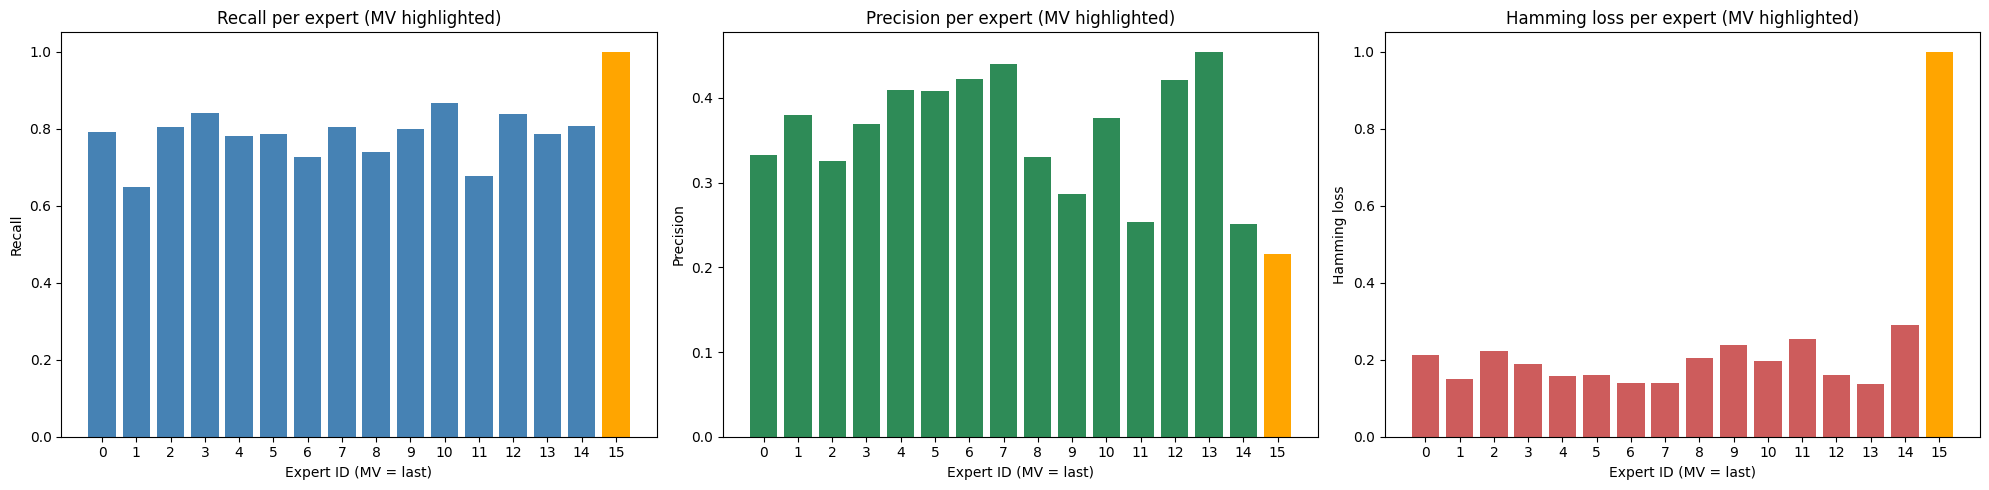

In [70]:
# write your code here

consensus_tags = p_hat[:, :, None]   # (N, K, 1)

exp_performance_recall = expert_performance(Y, consensus_tags, perf_fun=recall_fun)
exp_performance_precision = expert_performance(Y, consensus_tags, perf_fun=precision_fun)
exp_performance_hamming = expert_performance(Y, consensus_tags, perf_fun=hamming_fun)
print(exp_performance_recall)
print(exp_performance_precision)
print(exp_performance_hamming)

plot_expert_metrics_with_cv(Y, tags, consensus_tags, mode="argmax")


## 6. Train a model on the estimated labels 

Perform a random train-test (80-20) split of the dataset. 

Choose an ML algorithm and prepare three models. To make the comparison fair, use only those samples from the training subset that are annotated by at least one annotator:

- using the ground truth labels
- using the labels estimated by the majority voting algorithm
- using the labels estimated by the consensus voting algorithm
  
Evaluate the models on the test subset (using the ground truth labels). Repeat the process `5` times, compute the average score and standard deviation values. Present the results using a bar plot with error bars. 

Repeat the comparison/evaluation using cross-validation.

### Hints

**Use fast classification algorithm.**

**Hard vs. soft labels for training.** Consensus voting gives you a soft `(N, K)` matrix. Most sklearn classifiers expect a single class label per sample. Three options, in order of complexity:

1. *Hard labels:* take `np.argmax(p_hat, axis=1)` and train normally. Simple, throws away the uncertainty information.
2. *Confidence weighting:* take argmax labels as before, but pass `sample_weight=p_hat.max(axis=1)` to `fit`. Most sklearn classifiers accept this. Down-weights samples the consensus is unsure about, without changing the learning algorithm.
3. *True soft labels:* train a model that natively accepts a probability distribution as target - e.g. a small PyTorch / Keras MLP. Both `torch.nn.CrossEntropyLoss` and `tf.keras.losses.CategoricalCrossentropy` accept soft targets directly.

For this lab, option 1 is fine and keeps things comparable across the three label sources. Mention which you used.

**Filtering to "annotated" samples.** "Use only those samples - annotated by at least one annotator" means at least one non-NaN entry across both the class and annotator axes. Apply your mask **before** the train-test split, otherwise some test samples will be unannotated and you'll silently change what each repetition is evaluated on.

**Make the bar plot honest.** The error bars should be computed from the 5 repetitions per condition (std or 95% CI), not pooled across conditions. If two of your three bars overlap heavily, say so - that's a real finding about the labeling methods, not a failure of the experiment.




In [74]:
# write your code here
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

def run_single_experiment(X, Y, CV, annotated_mask, random_state):
    #train/test split na pełnym zbiorze
    idx_train, idx_test = train_test_split(np.arange(X.shape[0]), test_size=0.2, random_state=random_state, shuffle=True)

    #filtracja train po oznaczonych próbkach
    idx_train_annotated = idx_train[annotated_mask[idx_train]]
    
    #dane treningowe
    X_train_gt = X[idx_train_annotated]
    y_train_gt = Y[idx_train_annotated].argmax(axis=1).ravel()

    X_train_cv = X[idx_train_annotated]
    y_train_cv = CV[idx_train_annotated].argmax(axis=1).ravel()


    #dane testowe
    X_test = X[idx_test]
    y_test = Y[idx_test].argmax(axis=1).ravel()

    clf_gt = RandomForestClassifier(n_estimators=50, n_jobs=-1)
    clf_cv = RandomForestClassifier(n_estimators=50, n_jobs=-1)

    clf_gt.fit(X_train_gt, y_train_gt)
    clf_cv.fit(X_train_cv, y_train_cv)
    
    pred_gt = clf_gt.predict(X_test)
    pred_cv = clf_cv.predict(X_test)


    bac_gt = balanced_accuracy_score(y_test, pred_gt)
    bac_cv = balanced_accuracy_score(y_test, pred_cv)

    return bac_gt, bac_cv


In [75]:
annotated = ~np.isnan(tags[:, 0, :]).all(axis=1)

seeds = [13, 25, 42, 87, 124]
results_gt = []
results_cv = []

for seed in seeds:
    bac_gt, bac_cv = run_single_experiment(X, Y, consensus_tags, annotated, random_state=seed)
    results_gt.append(bac_gt)
    results_cv.append(bac_cv)

results_gt = np.array(results_gt)
results_cv = np.array(results_cv)


Nr	seed	GT BAC	CV BAC
0	13	0.9556	0.8877
1	25	0.9581	0.8926
2	42	0.9552	0.8915
3	87	0.9564	0.8901
4	124	0.9577	0.8908
GT mean: 0.9566, std: 0.001144
CV mean: 0.8905, std: 0.001652


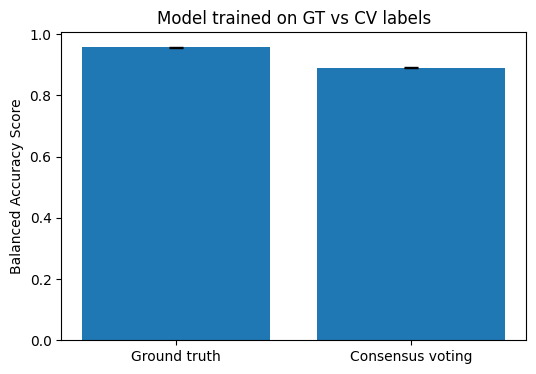

In [73]:
print(f"Nr\tseed\tGT BAC\tCV BAC")
for i, seed in enumerate(seeds):
    print(f"{i}\t{seed}\t{results_gt[i]:.4}\t{results_cv[i]:.4}")

print(f"GT mean: {results_gt.mean():.4}, std: {results_gt.std():.4}")
print(f"CV mean: {results_cv.mean():.4}, std: {results_cv.std():.4}")


means = [results_gt.mean(), results_cv.mean()]
stds = [results_gt.std(), results_cv.std()]

plt.figure(figsize=(6,4))
plt.bar(["Ground truth", "Consensus voting"], means, yerr=stds, capsize=5)
plt.ylabel("Balanced Accuracy Score")
plt.title("Model trained on GT vs CV labels")
plt.show()

### To samo z Cross-Validation

In [76]:
from sklearn.model_selection import KFold

def run_single_fold(X, Y, CV, annotated_mask, train_idx, test_idx):
    # maska po oznaczonych próbkach
    train_idx_annotated = train_idx[annotated_mask[train_idx]]

    # dane treningowe
    X_train_gt = X[train_idx_annotated]
    y_train_gt = Y[train_idx_annotated].argmax(axis=1).ravel()

    X_train_cv = X[train_idx_annotated]
    y_train_cv = CV[train_idx_annotated].argmax(axis=1).ravel()

    # dane testowe
    X_test = X[test_idx]
    y_test = Y[test_idx].argmax(axis=1).ravel()

    # modele
    clf_gt = RandomForestClassifier(n_estimators=50, n_jobs=-1)
    clf_cv = RandomForestClassifier(n_estimators=50, n_jobs=-1)

    clf_gt.fit(X_train_gt, y_train_gt)
    clf_cv.fit(X_train_cv, y_train_cv)

    pred_gt = clf_gt.predict(X_test)
    pred_cv = clf_cv.predict(X_test)

    # calanced accuracy
    bac_gt = balanced_accuracy_score(y_test, pred_gt)
    bac_cv = balanced_accuracy_score(y_test, pred_cv)

    return bac_gt, bac_cv


def run_cross_validation(X, Y, CV, annotated_mask, n_splits=5, seed=42, print_results=False):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    results_gt = []
    results_cv = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        bac_gt, bac_cv = run_single_fold(X, Y, CV, annotated_mask, train_idx, test_idx)
        results_gt.append(bac_gt)
        results_cv.append(bac_cv)
        if print_results:
            print(f"Fold {fold}: GT={bac_gt:.4f}, MV={bac_cv:.4f}")

    return np.array(results_gt), np.array(results_cv)


In [77]:
annotated = ~np.isnan(tags[:, 0, :]).all(axis=1)

results_gt_cv, results_cv_cv = run_cross_validation(X, Y, consensus_tags, annotated, n_splits=5, seed=123)

print(results_gt_cv)
print(results_cv_cv)


[0.95877321 0.95692791 0.95724878 0.95998453 0.95583342]
[0.88828617 0.88744153 0.89485586 0.89248971 0.89416448]



Cross-validation summary:
GT mean: 0.9578, std: 0.0015
MV mean: 0.8914, std: 0.0030


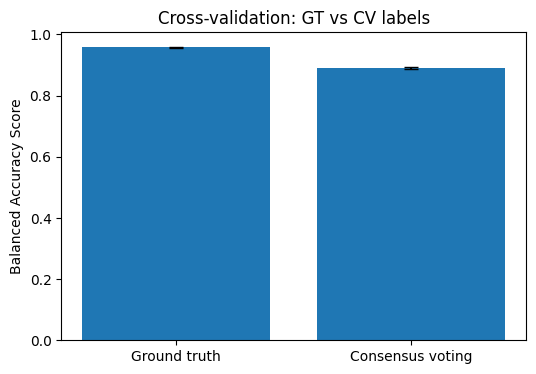

In [78]:
print("\nCross-validation summary:")
print(f"GT mean: {results_gt_cv.mean():.4f}, std: {results_gt_cv.std():.4f}")
print(f"MV mean: {results_cv_cv.mean():.4f}, std: {results_cv_cv.std():.4f}")

means = [results_gt_cv.mean(), results_cv_cv.mean()]
stds = [results_gt_cv.std(), results_cv_cv.std()]

plt.figure(figsize=(6,4))
plt.bar(["Ground truth", "Consensus voting"], means, yerr=stds, capsize=5)
plt.ylabel("Balanced Accuracy Score")
plt.title("Cross-validation: GT vs CV labels")
plt.show()



# 7. Final remarks
### What this approach can and can't do

The consensus voting algorithm in section 4 is powerful, but it rests on assumptions that are worth stating up front:

- **Independence.** It assumes annotators make their decisions independently. If your annotators talk to each other, copy from a shared reference, or all watched the same training video, this is violated and the model will overweight the resulting (correlated) errors.
- **Per-annotator constants.** Each annotator has fixed `TPR` and `TNR` regardless of the sample. In reality, an expert in cardiology may be excellent on heart MRIs and unreliable on brain MRIs. This is a real limitation; more sophisticated models (GLAD, item-response models) relax it.
- **Existence of ground truth.** The model assumes there *is* a true label, just that we can't see it. For genuinely subjective tasks (sentiment, aesthetics), the right framing might instead be "model the distribution of human judgments" rather than "recover the hidden truth."
- **Adversarial annotators.** A coordinated group of malicious labelers who agree among themselves can fool consensus methods just as well as they fool majority voting. EM does not magically detect bad faith.

None of these are reasons to avoid the method - they're reasons to know what you're doing when you apply it.
